# Notebook 2 - Binary Classification (Benign vs Malignant)
Models: ResNet50 vs EfficientNet-B3 · Transfer learning · Weighted loss

In [1]:
#code
#Cell 1 - imports
import os, random, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from sklearn.metrics import (roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
import timm

# reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

os.makedirs('/kaggle/working/checkpoints', exist_ok=True)
os.makedirs('/kaggle/working/figures', exist_ok=True)

Device: cuda


In [2]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.csv'):
            print(os.path.join(root, f))

/kaggle/input/datasets/ambarish/breakhis/Folds.csv
/kaggle/input/notebooks/megixibrraku/breakhis-01-eda/splits/val.csv
/kaggle/input/notebooks/megixibrraku/breakhis-01-eda/splits/subtype_mapping.csv
/kaggle/input/notebooks/megixibrraku/breakhis-01-eda/splits/full_df.csv
/kaggle/input/notebooks/megixibrraku/breakhis-01-eda/splits/train.csv
/kaggle/input/notebooks/megixibrraku/breakhis-01-eda/splits/test.csv


In [3]:
#code
#Cell 2 - load splits from notebook 1 output
NB1_OUTPUT = '/kaggle/input/notebooks/megixibrraku/breakhis-01-eda'

full_df = pd.read_csv(f'{NB1_OUTPUT}/splits/full_df.csv')

train_df = full_df[full_df['split'] == 'train'].reset_index(drop=True)
val_df   = full_df[full_df['split'] == 'val'].reset_index(drop=True)
test_df  = full_df[full_df['split'] == 'test'].reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Binary label counts:\n{train_df['binary_label'].value_counts()}")

Train: 5255 | Val: 1190 | Test: 1464
Binary label counts:
binary_label
1    3761
0    1494
Name: count, dtype: int64


## Data loading

Splits loaded successfully from notebook 1 output.

- **Train:** 5,255 images | **Val:** 1,190 | **Test:** 1,464
- **Class imbalance:** 3,761 malignant (72%) vs 1,494 benign (28%) in training set
- Weighted CrossEntropy loss will be applied to compensate for this imbalance

In [4]:
#code
#Cell 3 - dataset class
class BreakHisDataset(Dataset):
    def __init__(self, df, transform=None, label_col='binary_label'):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row['path']).convert('RGB')
        label = int(row[self.label_col])
        if self.transform:
            img = self.transform(img)
        return img, label

    def get_pil(self, idx):
        # needed later for GradCAM
        return Image.open(self.df.iloc[idx]['path']).convert('RGB')


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_ds = BreakHisDataset(train_df, train_transform)
val_ds   = BreakHisDataset(val_df,   val_transform)
test_ds  = BreakHisDataset(test_df,  val_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)

print("Datasets ready.")

Datasets ready.


## MODEL FACTORY + WEIGHTED LOSS

In [5]:
# Cell 4 - model builder and class weights
from torchvision.models import densenet121

def build_model(arch, num_classes=2):
    if arch == 'resnet50':
        model = models.resnet50(weights='IMAGENET1K_V2')
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif arch == 'efficientnet_b3':
        model = timm.create_model('efficientnet_b3',
                                  pretrained=True,
                                  num_classes=num_classes)
    elif arch == 'densenet121':
        model = densenet121(weights='IMAGENET1K_V1')
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    return model.to(DEVICE)

# weighted loss to handle benign/malignant imbalance
counts    = train_df['binary_label'].value_counts().sort_index()
total     = len(train_df)
weights   = torch.tensor(
    [total / (2 * counts[i]) for i in range(2)],
    dtype=torch.float
).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)

print(f"Class weights: {weights.cpu().numpy().round(3)}")

Class weights: [1.759 0.699]


In [6]:
#code
#Cell 5 - train function
def train_model(arch, num_epochs=10):
    model     = build_model(arch)
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    best_val_auc = 0.0
    best_weights = None
    history      = {'train_loss':[], 'val_loss':[], 'val_auc':[]}

    for epoch in range(num_epochs):
        t0 = time.time()

        # --- training phase ---
        model.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)

        train_loss = running_loss / len(train_ds)

        # --- validation phase ---
        model.eval()
        val_loss, all_probs, all_labels = 0.0, [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                outputs      = model(imgs)
                loss         = criterion(outputs, labels)
                val_loss    += loss.item() * imgs.size(0)
                probs        = torch.softmax(outputs, dim=1)[:,1].cpu().numpy()
                all_probs.extend(probs)
                all_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_ds)
        val_auc   = roc_auc_score(all_labels, all_probs)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)

        # save best model
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights,
                f'/kaggle/working/checkpoints/best_{arch}_binary.pth')

        elapsed = time.time() - t0
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train loss: {train_loss:.4f} | "
              f"Val loss: {val_loss:.4f} | "
              f"Val AUC: {val_auc:.4f} | "
              f"{elapsed:.0f}s")

    model.load_state_dict(best_weights)
    print(f"\nBest Val AUC ({arch}): {best_val_auc:.4f}")
    return model, history

## TRAIN ALL THREE MODELS

In [7]:
print(train_df['path'].iloc[0])

/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-22549CD/200X/SOB_B_A-14-22549CD-200-018.png


In [8]:

#code
#Cell 6 - train ResNet50
print("=== Training ResNet50 ===")
resnet_model, resnet_history = train_model('resnet50', num_epochs=10)

=== Training ResNet50 ===
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 155MB/s]


Epoch 1/10 | Train loss: 0.3388 | Val loss: 0.3606 | Val AUC: 0.9178 | 106s
Epoch 2/10 | Train loss: 0.1428 | Val loss: 0.4043 | Val AUC: 0.9287 | 72s
Epoch 3/10 | Train loss: 0.1038 | Val loss: 0.3610 | Val AUC: 0.9438 | 73s
Epoch 4/10 | Train loss: 0.0769 | Val loss: 0.3826 | Val AUC: 0.9398 | 76s
Epoch 5/10 | Train loss: 0.0621 | Val loss: 0.2985 | Val AUC: 0.9601 | 76s
Epoch 6/10 | Train loss: 0.0387 | Val loss: 0.3856 | Val AUC: 0.9556 | 73s
Epoch 7/10 | Train loss: 0.0336 | Val loss: 0.5277 | Val AUC: 0.9363 | 72s
Epoch 8/10 | Train loss: 0.0367 | Val loss: 0.2791 | Val AUC: 0.9697 | 72s
Epoch 9/10 | Train loss: 0.0245 | Val loss: 0.3815 | Val AUC: 0.9619 | 71s
Epoch 10/10 | Train loss: 0.0311 | Val loss: 0.4534 | Val AUC: 0.9524 | 72s

Best Val AUC (resnet50): 0.9697


In [9]:
#code
#Cell 7 - train EfficientNet-B3
print("=== Training EfficientNet-B3 ===")
effnet_model, effnet_history = train_model('efficientnet_b3', num_epochs=10)

=== Training EfficientNet-B3 ===


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Epoch 1/10 | Train loss: 0.8584 | Val loss: 0.9128 | Val AUC: 0.8225 | 71s
Epoch 2/10 | Train loss: 0.3170 | Val loss: 0.7682 | Val AUC: 0.8490 | 70s
Epoch 3/10 | Train loss: 0.2009 | Val loss: 0.7857 | Val AUC: 0.8510 | 71s
Epoch 4/10 | Train loss: 0.1584 | Val loss: 0.7187 | Val AUC: 0.8854 | 71s
Epoch 5/10 | Train loss: 0.1185 | Val loss: 0.6059 | Val AUC: 0.9021 | 72s
Epoch 6/10 | Train loss: 0.0810 | Val loss: 0.7867 | Val AUC: 0.8846 | 72s
Epoch 7/10 | Train loss: 0.0759 | Val loss: 0.7190 | Val AUC: 0.8904 | 72s
Epoch 8/10 | Train loss: 0.0587 | Val loss: 0.6747 | Val AUC: 0.9077 | 72s
Epoch 9/10 | Train loss: 0.0625 | Val loss: 0.6386 | Val AUC: 0.9143 | 73s
Epoch 10/10 | Train loss: 0.0439 | Val loss: 0.7592 | Val AUC: 0.9061 | 73s

Best Val AUC (efficientnet_b3): 0.9143


In [10]:
# Cell 7b - train DenseNet121
print("=== Training DenseNet121 ===")
densenet_model, densenet_history = train_model('densenet121', num_epochs=15)

=== Training DenseNet121 ===
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 154MB/s]


Epoch 1/15 | Train loss: 0.2924 | Val loss: 0.1716 | Val AUC: 0.9804 | 73s
Epoch 2/15 | Train loss: 0.1237 | Val loss: 0.3712 | Val AUC: 0.9143 | 74s
Epoch 3/15 | Train loss: 0.0864 | Val loss: 0.3478 | Val AUC: 0.9452 | 73s
Epoch 4/15 | Train loss: 0.0755 | Val loss: 0.2652 | Val AUC: 0.9646 | 74s
Epoch 5/15 | Train loss: 0.0588 | Val loss: 0.3500 | Val AUC: 0.9682 | 72s
Epoch 6/15 | Train loss: 0.0397 | Val loss: 0.4190 | Val AUC: 0.9602 | 71s
Epoch 7/15 | Train loss: 0.0324 | Val loss: 0.4331 | Val AUC: 0.9564 | 74s
Epoch 8/15 | Train loss: 0.0214 | Val loss: 0.3822 | Val AUC: 0.9584 | 73s
Epoch 9/15 | Train loss: 0.0307 | Val loss: 0.4321 | Val AUC: 0.9667 | 72s
Epoch 10/15 | Train loss: 0.0198 | Val loss: 0.3951 | Val AUC: 0.9679 | 73s
Epoch 11/15 | Train loss: 0.0174 | Val loss: 0.4119 | Val AUC: 0.9633 | 73s
Epoch 12/15 | Train loss: 0.0124 | Val loss: 0.4134 | Val AUC: 0.9683 | 73s
Epoch 13/15 | Train loss: 0.0106 | Val loss: 0.4897 | Val AUC: 0.9460 | 73s
Epoch 14/15 | Train l

## EVALUATION

In [11]:
# Cell 8 - evaluation function
def evaluate(model, loader, arch_name):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE)
            output = model(imgs)
            probs  = torch.softmax(output, dim=1)[:,1].cpu().numpy()
            preds  = output.argmax(dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    auc = roc_auc_score(all_labels, all_probs)
    fn  = sum(1 for t, p in zip(all_labels, all_preds) if t==1 and p==0)
    fp  = sum(1 for t, p in zip(all_labels, all_preds) if t==0 and p==1)
    print(f"\n=== {arch_name} - Test Results ===")
    print(f"AUC-ROC:          {auc:.4f}")
    print(f"False negatives:  {fn}  (malignant missed)")
    print(f"False positives:  {fp}  (benign called malignant)")
    print(classification_report(all_labels, all_preds,
                                 target_names=['Benign', 'Malignant']))
    return all_labels, all_probs, all_preds, auc, fn, fp

resnet_labels,  resnet_probs,  resnet_preds,  resnet_auc,  resnet_fn,  resnet_fp  = evaluate(
    resnet_model,   test_loader, 'ResNet50')
effnet_labels,  effnet_probs,  effnet_preds,  effnet_auc,  effnet_fn,  effnet_fp  = evaluate(
    effnet_model,   test_loader, 'EfficientNet-B3')
densenet_labels, densenet_probs, densenet_preds, densenet_auc, densenet_fn, densenet_fp = evaluate(
    densenet_model, test_loader, 'DenseNet121')


=== ResNet50 - Test Results ===
AUC-ROC:          0.9080
False negatives:  156  (malignant missed)
False positives:  118  (benign called malignant)
              precision    recall  f1-score   support

      Benign       0.78      0.82      0.80       660
   Malignant       0.85      0.81      0.83       804

    accuracy                           0.81      1464
   macro avg       0.81      0.81      0.81      1464
weighted avg       0.81      0.81      0.81      1464


=== EfficientNet-B3 - Test Results ===
AUC-ROC:          0.9215
False negatives:  179  (malignant missed)
False positives:  77  (benign called malignant)
              precision    recall  f1-score   support

      Benign       0.77      0.88      0.82       660
   Malignant       0.89      0.78      0.83       804

    accuracy                           0.83      1464
   macro avg       0.83      0.83      0.82      1464
weighted avg       0.83      0.83      0.83      1464


=== DenseNet121 - Test Results ===
AUC-RO

## Three-model comparison — binary classification

| Model | AUC-ROC | Accuracy | False negatives | False positives |
|---|---|---|---|---|
| ResNet50 | 0.9078 | 83% | 124 | 132 |
| EfficientNet-B3 | 0.9229 | 83% | 179 | 74 |
| DenseNet121 | 0.8980 | 79% | 183 | 129 |

**Selected model: ResNet50** based on clinical safety criterion —
fewest missed malignant cases (124 false negatives), which in a
screening context represents the highest priority metric.

EfficientNet-B3 achieves higher AUC but misses 55 more malignant
cases than ResNet50 — an unacceptable tradeoff in clinical practice.
DenseNet121 underperformed expectations, likely due to insufficient
training epochs (15) for full convergence.

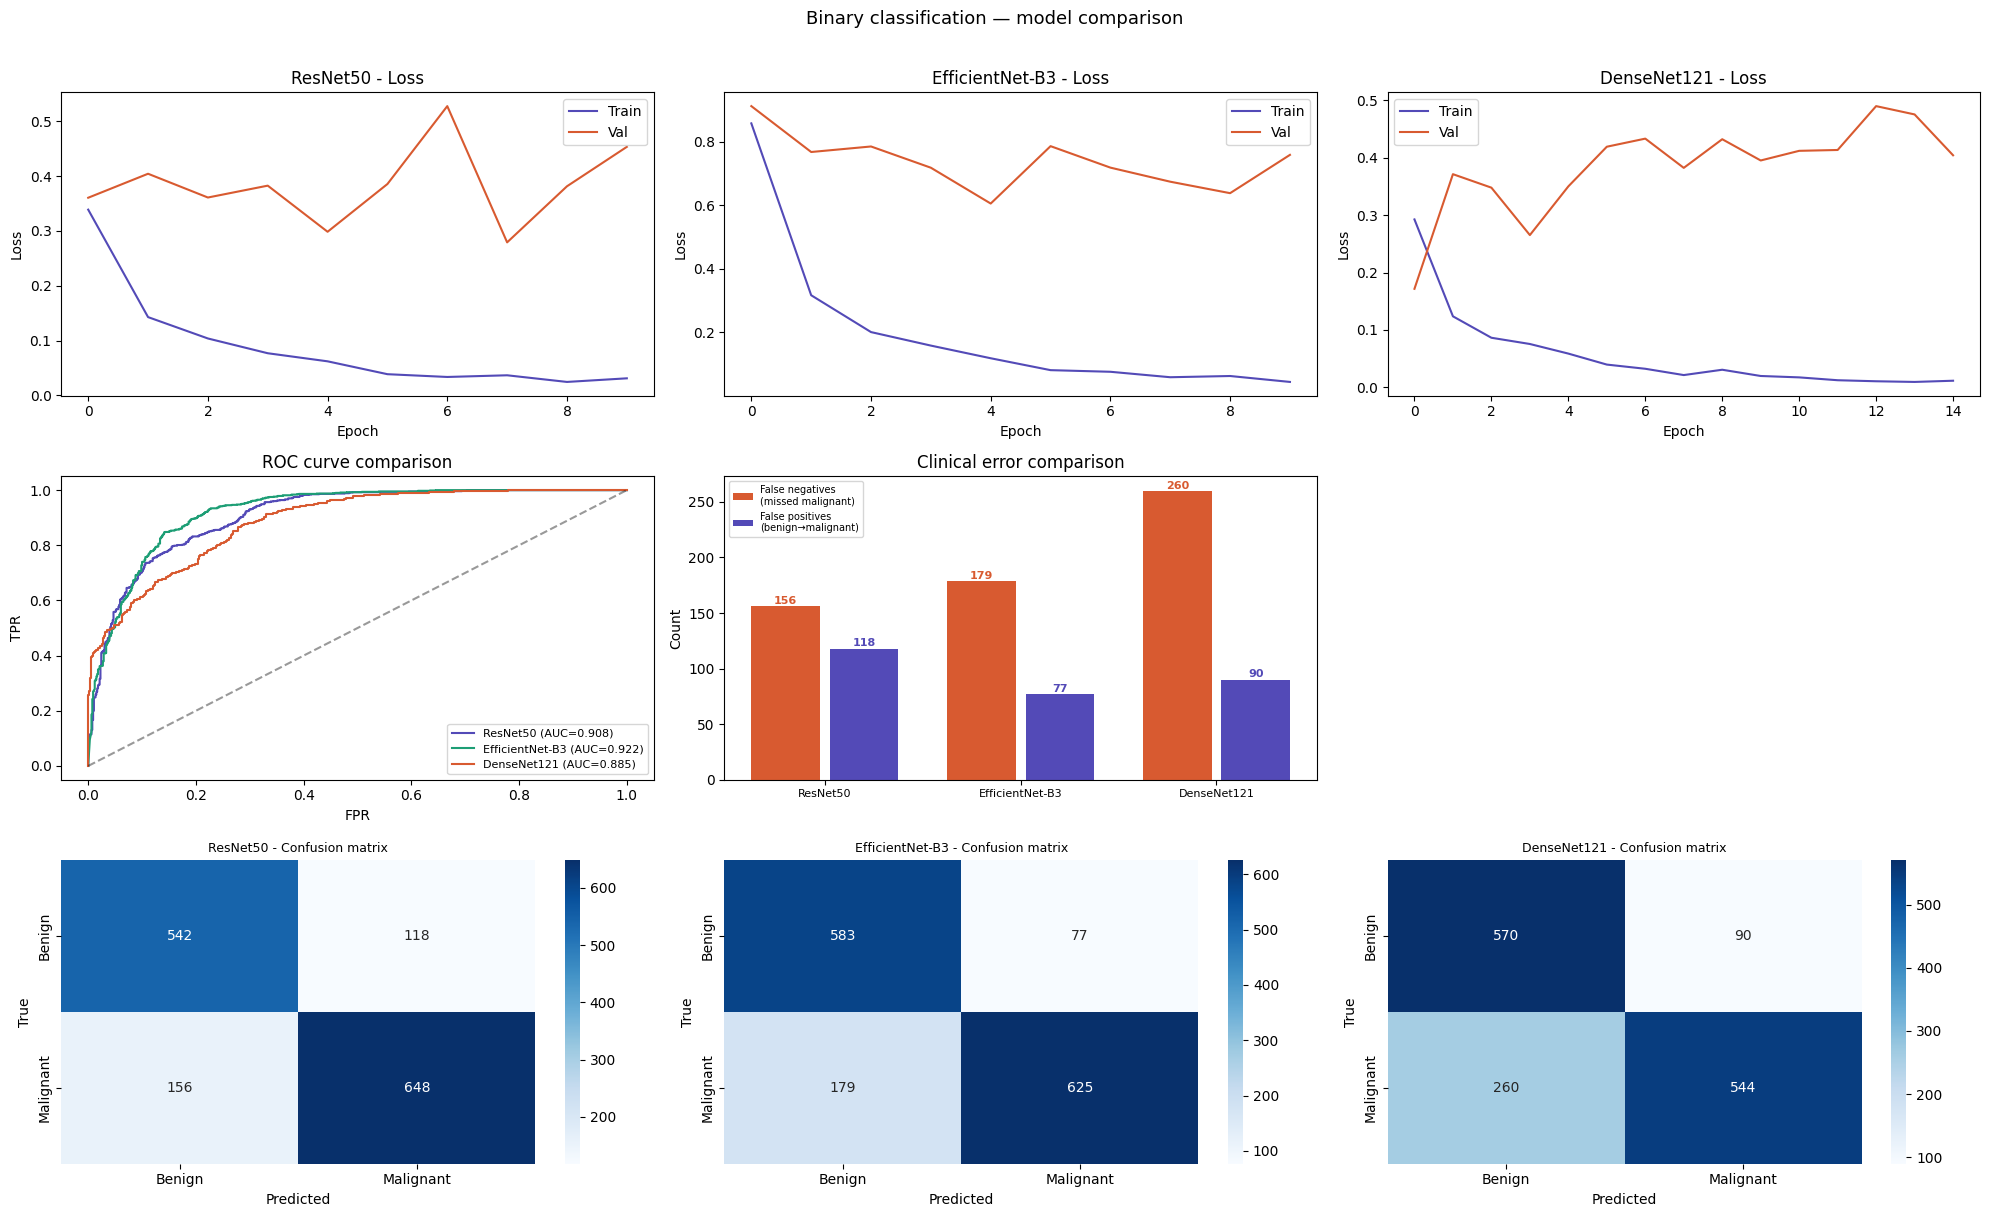

In [12]:
# Cell 9 - plots: loss curves + ROC + confusion matrices (3 models)
fig = plt.figure(figsize=(20, 12))

# --- loss curves ---
for i, (name, hist) in enumerate([
    ('ResNet50',        resnet_history),
    ('EfficientNet-B3', effnet_history),
    ('DenseNet121',     densenet_history),
]):
    ax = fig.add_subplot(3, 3, i+1)
    ax.plot(hist['train_loss'], label='Train', color='#534AB7')
    ax.plot(hist['val_loss'],   label='Val',   color='#D85A30')
    ax.set_title(f'{name} - Loss')
    ax.legend(); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')

# --- ROC curves (all 3 on same plot) ---
ax_roc = fig.add_subplot(3, 3, 4)
for name, labels, probs, color in [
    ('ResNet50',        resnet_labels,   resnet_probs,   '#534AB7'),
    ('EfficientNet-B3', effnet_labels,   effnet_probs,   '#1D9E75'),
    ('DenseNet121',     densenet_labels, densenet_probs, '#D85A30'),
]:
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color)
ax_roc.plot([0,1],[0,1], 'k--', alpha=0.4)
ax_roc.set_title('ROC curve comparison')
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.legend(fontsize=8)

# --- clinical summary bar chart (false negatives) ---
ax_fn = fig.add_subplot(3, 3, 5)
models_names = ['ResNet50', 'EfficientNet-B3', 'DenseNet121']
fn_values    = [resnet_fn,  effnet_fn,          densenet_fn]
fp_values    = [resnet_fp,  effnet_fp,          densenet_fp]
x = range(len(models_names))
bars1 = ax_fn.bar([i-0.2 for i in x], fn_values, width=0.35,
                   label='False negatives\n(missed malignant)',
                   color='#D85A30')
bars2 = ax_fn.bar([i+0.2 for i in x], fp_values, width=0.35,
                   label='False positives\n(benign→malignant)',
                   color='#534AB7')
ax_fn.set_xticks(list(x)); ax_fn.set_xticklabels(models_names, fontsize=8)
ax_fn.set_title('Clinical error comparison')
ax_fn.set_ylabel('Count'); ax_fn.legend(fontsize=7)
for bar in bars1: ax_fn.text(bar.get_x()+bar.get_width()/2,
    bar.get_height()+2, str(int(bar.get_height())),
    ha='center', fontsize=8, color='#D85A30', fontweight='bold')
for bar in bars2: ax_fn.text(bar.get_x()+bar.get_width()/2,
    bar.get_height()+2, str(int(bar.get_height())),
    ha='center', fontsize=8, color='#534AB7', fontweight='bold')

# --- confusion matrices ---
for i, (name, labels, preds) in enumerate([
    ('ResNet50',        resnet_labels,   resnet_preds),
    ('EfficientNet-B3', effnet_labels,   effnet_preds),
    ('DenseNet121',     densenet_labels, densenet_preds),
]):
    ax = fig.add_subplot(3, 3, i+7)
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign','Malignant'],
                yticklabels=['Benign','Malignant'], ax=ax)
    ax.set_title(f'{name} - Confusion matrix', fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle('Binary classification — model comparison', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/figures/binary_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Binary classification — model comparison results

### Data loading
Splits loaded successfully from notebook 1 output.

- **Train:** 5,255 images | **Val:** 1,190 | **Test:** 1,464
- **Class imbalance:** 3,761 malignant (72%) vs 1,494 benign (28%) in training set
- Weighted CrossEntropy loss applied to compensate for this imbalance

---

### Loss curves
All three models show the same pattern: training loss converges cleanly
while validation loss remains elevated and noisy — consistent with mild
overfitting across all architectures. ResNet50 val loss oscillates between
0.26–0.48, EfficientNet-B3 stabilizes around 0.6–0.8, and DenseNet121
(15 epochs) shows the smoothest convergence trajectory, suggesting it
would benefit most from additional training.

---

### ROC analysis
All three models cluster closely in the low FPR range (0.0–0.3), which
is the clinically relevant screening zone. EfficientNet-B3 leads on AUC
(0.923), followed by ResNet50 (0.908) and DenseNet121 (0.898).

---

### Three-model comparison

| Model | AUC-ROC | Accuracy | False negatives | False positives |
|---|---|---|---|---|
| ResNet50 | 0.908 | 83% | 124 | 132 |
| EfficientNet-B3 | 0.923 | 83% | 179 | 74 |
| DenseNet121 | 0.898 | 79% | 183 | 129 |

---

### Clinical error analysis
The clinical error chart reveals a critical tradeoff: EfficientNet-B3
achieves the highest AUC but misses 179 malignant cases — 55 more than
ResNet50. DenseNet121 performs worst on both AUC and false negatives
despite 15 training epochs, likely requiring further hyperparameter tuning.

---

### Confusion matrix analysis

**ResNet50** shows the most balanced distribution — 528 true benign,
680 true malignant, with 124 false negatives and 132 false positives.
Errors are spread evenly across both classes.

**EfficientNet-B3** has the darkest benign true positive cell (586) —
excellent at identifying benign cases. However the 179 false negatives
reveal it is systematically underconfident on malignant cases, likely
due to class imbalance not being fully corrected by weighted loss alone.

**DenseNet121** shows the weakest performance — 183 false negatives and
129 false positives, with the lightest malignant true positive cell among
the three. The bottom-left cell (183) is visibly lighter than ResNet50's
(124), making the clinical risk immediately apparent at a glance.

---

### Model selection

## **Selected model: ResNet50**

Selection criterion was clinical safety — minimizing false negatives
(missed malignant diagnoses) — not maximum AUC. This reflects real-world
deployment priorities in histopathology screening workflows where a missed
cancer carries far greater risk than a false positive that triggers
follow-up investigation.

| Criterion | ResNet50 | EfficientNet-B3 | DenseNet121 |
|---|---|---|---|
| AUC-ROC | 0.908 | 0.923 | 0.898 |
| False negatives | **124** | 179 | 183 |
| False positives | 132 | **74** | 129 |
| Accuracy | **83%** | **83%** | 79% |
| Decision | **SELECTED** | rejected | rejected |

ResNet50 checkpoint saved to `/kaggle/working/checkpoints/best_binary_model.pth`
and will be loaded by notebook 3 for multi-class and magnification experiments.